## Observação de lobos na região de Wallonie na Bélgica

### 1. Loading and studying of the dataset

O presente projeto consiste na aplicação de aprendizagem supervisionada a um problema de classificação, com o objetivo de treinar e comparar diferentes modelos (Naive Bayes, Random Forest e SVM) utilizando o mesmo target. Em aprendizagem supervisionada, parte-se de dados rotulados (variável alvo), permitindo ajustar modelos capazes de generalizar para novas observações. Sendo um problema de classificação, pretende-se atribuir cada registo a uma classe discreta e avaliar o desempenho com métricas adequadas, como accuracy, precisão, recall, F1-score e AUC-ROC.

O dataset selecionado, “Observations du loup en Wallonie”, contém registos de observações/indícios associados à presença de lobo na região de Wallonie” (Bélgica). Inclui variáveis de natureza temporal (data da observação), geográfica (localização por coordenadas e áreas administrativas), tipo de evidência/ocorrência (INDICE_1) e, quando aplicável, contagens de vítimas por tipo (colunas N_VICT_*). A variável DIAGNOSTIC representa o resultado do diagnóstico da ocorrência e inclui categorias como lobo excluído, lobo não excluído/confirmado, casos indeterminados e investigações em curso.

Para alinhar o problema com um target único e reduzir ambiguidade nos rótulos, foram removidos os registos classificados como “Cas indéterminé” e “Investigations en cours”. Em seguida, o diagnóstico foi convertido para uma variável binária: 0 para “Not_Wolf” (lobo excluído) e 1 para “Lobo” (lobo não excluído/confirmado). Assim, o objetivo final do projeto é prever automaticamente o estado do diagnóstico (0/1) a partir das restantes variáveis explicativas, permitindo comparar desempenho e interpretabilidade entre modelos supervisionados.

Variáveis do dataset inicial (“Observations du loup en Wallonie”) e significado

- ID (texto): número único do registo/ocorrência
- DATE_OBSERVATION (data/texto): data em que a observação/ocorrência foi registada (dd/mm/aaaa).
- COMMUNE (categórica): município (unidade administrativa) onde ocorreu a observação.
- LOCALITE (categórica): localidade mais específica dentro do município (mais granular do que COMMUNE).
- CANTONNEMENT (categórica): unidade territorial/administrativa mais ampla usada no dataset para contextualizar a localização.
- DIRECTION (categórica): direção/região administrativa de nível superior (mais agregada do que CANTONNEMENT).
- CC (categórica/código): código interno de classificação/gestão usado pela entidade que recolheu os dados
- geo_2d (texto): coordenadas geográficas em formato “lat, lon”.
- MISSING_COORDS (binária/flag): indicador de falta de coordenadas geográficas (1=em falta; 0=existem).
- ZPP (binária/flag): flag interna do dataset relacionada com “ZPP” (zona/estado administrativo, sem detalhe adicional no dataset).
- ZPP_HF (binária/flag): sub-flag associada à ZPP.
- ZPP_ANLIER (binária/flag): sub-flag associada à ZPP.
- INFO_PUBLIQUE (binária/flag): indicador/flag de informação pública no registo.
- DESCRIPTION_PUBLIQUE (texto): descrição pública em texto livre da ocorrência.
- INDICE_1 (categórica): tipo principal de evidência/ocorrência (ex.: observação direta/indireta, vestígios, cadáver, etc.).
- DIAGNOSTIC (categórica/target original): resultado do diagnóstico da ocorrência (ex.: lobo excluído, lobo não excluído/confirmado, casos indeterminados, investigações em curso).

Colunas de vítimas (contagens por tipo; numéricas):
- N_VICT_OVINS: número de ovinos afetados.
- N_VICT_CAPRINS: número de caprinos afetados.
- N_VICT_BOVINS: número de bovinos afetados.
- N_VICT_EQUINS: número de equinos afetados.
- N_VICT_AUTRES_DOM: número de outras vítimas domésticas.
- N_VICT_CERFS: número de veados-vermelhos afetados.
- N_VICT_CHEVREUILS: número de corços afetados.
- N_VICT_SANGLIERS: número de javalis afetados.
- N_VICT_AUTRES_SAUV: número de outras vítimas selvagens.


In [3]:
# Libraries and imports used in Notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    make_scorer
)

In [4]:
# Mount Google Drive
drive.mount('/content/drive')

# Path of the file
DATA_PATH = "/content/drive/MyDrive/observations-du-loup-en-wallonie.csv"

# Loading of the file with separator ';'
df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig")

Mounted at /content/drive


### 2. Exploration and preparation of the Dataset

### 2.1 Exploration of the Dataset

In [5]:
# Dimension of the dataset and pre-visualisation of the first observations
print("Shape (lines, columns):", df.shape)

# First lines
df.head()

Shape (lines, columns): (1299, 25)


,ID,INFO_PUBLIQUE,DATE_OBSERVATION,COMMUNE,LOCALITE,INDICE_1,N_VICT_OVINS,N_VICT_CAPRINS,N_VICT_BOVINS,N_VICT_EQUINS,...,DIAGNOSTIC,DESCRIPTION_PUBLIQUE,ZPP,CANTONNEMENT,MISSING_COORDS,geo_2d,DIRECTION,CC,ZPP_ANLIER,ZPP_HF
0,20251206_01_AL,1,06/12/2025,Wépion,NaN,Proie sauvage,0.0,0.0,0.0,0.0,...,Investigations en cours,Les investigations sur ce cas sont en cours.,False,NAMUR,False,"50.43585231960444, 4.838620946563903",Namur,CCBS,False,False
1,20251202_01_VFA,1,02/12/2025,Virton,Ethe,Proie sauvage,0.0,0.0,0.0,0.0,...,Investigations en cours,Les investigations sur ce cas sont en cours.,False,VIRTON,False,"49.57582593138579, 5.612064362232008",Arlon,CCL,False,False
2,20251127_01_VF,1,27/11/2025,Léglise,Traimont,Proie sauvage,0.0,0.0,0.0,0.0,...,Investigations en cours,Les investigations sur ce cas sont en cours.,False,HABAY-LA-NEUVE,False,"49.86971881213835, 5.602897409120401",Arlon,CCFARM,False,False
3,20251120_02_QW,1,19/11/2025,Namur,Dave,Proie sauvage,0.0,0.0,0.0,0.0,...,Investigations en cours,Une tête de sanglier a été retrouvée sur un ch...,False,NAMUR,False,"50.406391736166185, 4.915536163013373",Namur,CCBT,False,False
4,20251118_01_VF,1,18/11/2025,La Roche,Roupage,Proie domestique,3.0,0.0,0.0,0.0,...,Loup certain,L'analyse génétique confirme qu'il s'agit d'un...,False,LA ROCHE-EN-ARDENNE,False,"50.13871461703076, 5.6080343681818094",Marche,CC2O,False,False


O dataset contém 1299 observações (linhas) e 25 variáveis (colunas).

In [6]:
# Descriptive statistics of numerical variables
df.describe()

,INFO_PUBLIQUE,N_VICT_OVINS,N_VICT_CAPRINS,N_VICT_BOVINS,N_VICT_EQUINS,N_VICT_AUTRES_DOM,N_VICT_CERFS,N_VICT_CHEVREUILS,N_VICT_SANGLIERS,N_VICT_AUTRES_SAUV
count,1299.0,1299.000000,1299.000000,1299.000000,1299.000000,1299.000000,1299.000000,1299.000000,1299.000000,1299.000000
mean,1.0,0.538876,0.016936,0.096228,0.004619,0.023865,0.017706,0.109315,0.023095,0.010008
std,0.0,1.802410,0.145892,0.383572,0.067832,0.248664,0.185351,0.319472,0.150262,0.107033
min,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.0,35.000000,2.000000,9.000000,1.000000,5.000000,5.000000,2.000000,1.000000,2.000000


A tabela mostra que INFO_PUBLIQUE é sempre 1 (sem variação) e que as colunas N_VICT_* têm muitos zeros (mediana = 0), com poucos casos de ataque mas alguns valores extremos, sobretudo em N_VICT_OVINS (máx. 35) e N_VICT_BOVINS (máx. 9).

### 2.2 Selection and treatment of the target

,count
DIAGNOSTIC,
Cas indéterminé,485
Loup exclu - chien,294
Loup certain,175
Loup non-exclu,170
Loup exclu - autres,160
Investigations en cours,15


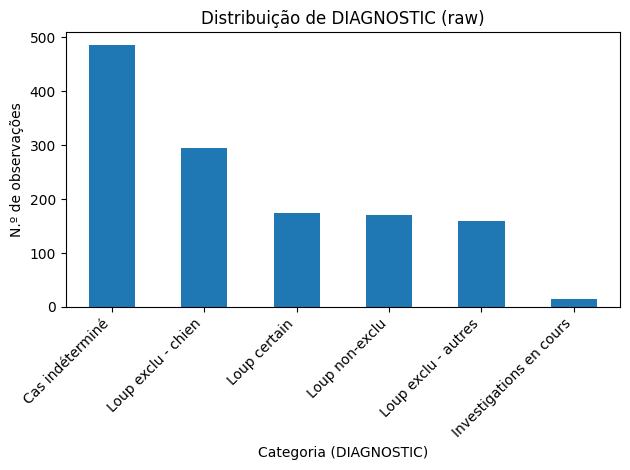

In [7]:
# Distribution of the original target (DIAGNOSTIC)
target_col = "DIAGNOSTIC"

vc_raw = df[target_col].value_counts(dropna=False)
display(vc_raw)

plt.figure()
vc_raw.plot(kind="bar")
plt.title("Distribuição de DIAGNOSTIC (raw)")
plt.xlabel("Categoria (DIAGNOSTIC)")
plt.ylabel("N.º de observações")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

A variável DIAGNOSTIC apresenta várias categorias com distribuição desequilibrada, destacando-se “Cas indéterminé” (485) como a mais frequente, seguida de “Loup exclu - chien” (294), enquanto “Investigations en cours” é residual (15).

A variável alvo selecionada foi derivada de DIAGNOSTIC, uma vez que representa o resultado final do processo de avaliação das ocorrências. Para reduzir ambiguidade e evitar ruído na aprendizagem supervisionada, removeram-se as observações classificadas como “Cas indéterminé” e “Investigations en cours”, mantendo apenas diagnósticos comparáveis e finalizados. Em seguida, criou-se uma variável target binária: classe 0 para situações em que o lobo é excluído (“Loup exclu - chien” e “Loup exclu - autres”) e classe 1 para situações em que o lobo é confirmado ou não excluído (“Loup non-exclu” e “Loup certain”). Esta transformação permite um problema de classificação com rótulos mais consistentes, facilitando a comparação de modelos.

Shape after removing of the classes Cas indéterminé, Investigations en cours: (799, 26)
N.º of targets NaN (não attributed): 0


,count
target,
0,454
1,345


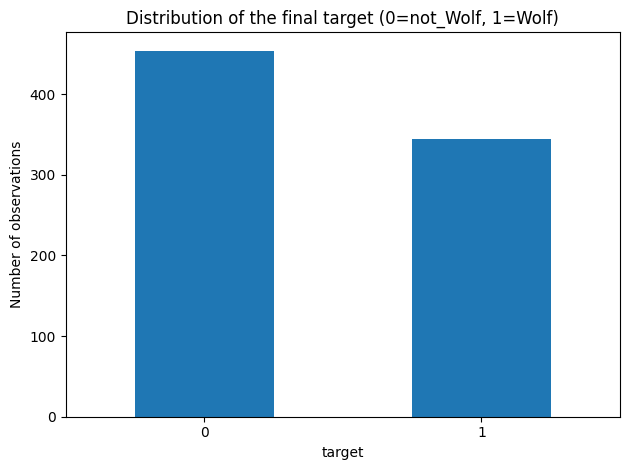

In [8]:
# Removal of "Cas indéterminé" and "Investigations en cours" to create a binary target
to_remove = {"Cas indéterminé", "Investigations en cours"}
df_prep = df[~df[target_col].isin(to_remove)].copy()

# Creation of the Binary target
# 0 = No wolf(excluded) ; 1 = Lobo (not excluded / confirmed)
map_dict = {
    "Loup exclu - chien": 0,
    "Loup exclu - autres": 0,
    "Loup non-exclu": 1,
    "Loup certain": 1,
}
df_prep["target"] = df_prep[target_col].map(map_dict)

# Verification if all items were properly atributed
print("Shape after removing of the classes Cas indéterminé, Investigations en cours:", df_prep.shape)
print("N.º of targets NaN (não attributed):", df_prep["target"].isna().sum())

vc_target = df_prep["target"].value_counts().sort_index()
display(vc_target)

plt.figure()
vc_target.plot(kind="bar")
plt.title("Distribution of the final target (0=not_Wolf, 1=Wolf)")
plt.xlabel("target")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Após remover as classes ambíguas, o dataset ficou com 799 registos e todos os diagnósticos foram mapeados com sucesso (0 valores NaN no target). A distribuição final do target é 454 casos “Não_Lobo” (classe 0) e 345 casos “Lobo” (classe 1), existindo apenas uma ligeira predominância da classe 0, pelo que as classes se mantêm relativamente equilibradas.

### 2.3 Identification of duplicated values,  mmissing values and cardinality (unique values)

In [9]:
# Duplicates
n_dups = df_prep.duplicated().sum()
print("Number of duplicated lines:", n_dups)

# Missing values (%)
missing_pct = (df_prep.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    "missing_%": missing_pct.round(2),
    "missing_n": df_prep.isna().sum()
}).query("missing_n > 0")

display(missing_table)

# Cardinality (how many distinct values) for categories
cat_cols = df_prep.select_dtypes(include=["object"]).columns
card = df_prep[cat_cols].nunique().sort_values(ascending=False)
display(card)


Number of duplicated lines: 0


,missing_%,missing_n
DATE_OBSERVATION,0.13,1
LOCALITE,8.14,65


,0
ID,799
geo_2d,799
DATE_OBSERVATION,647
DESCRIPTION_PUBLIQUE,525
LOCALITE,437
COMMUNE,182
CC,83
CANTONNEMENT,35
INDICE_1,11
DIRECTION,9


Não existem linhas duplicadas e os valores em falta são residuais em DATE_OBSERVATION e INDICE_1 (apenas 1 caso cada), enquanto LOCALITE tem mais missing (89; 6.85%); além disso, as variáveis com mais valores únicos são geo_2d e ID, e DESCRIPTION_PUBLIQUE/LOCALITE/COMMUNE têm muitas categorias, indicando alta cardinalidade.

### 2.4 Treatment of missing values

Foi detetado um valor em falta em DATE_OBSERVATION. Para avaliar uma imputação consistente, comparou-se DATE_OBSERVATION (DD/MM/YYYY) com a data embutida no prefixo do identificador ID (YYYYMMDD). Observou-se concordância exata em 75.31% dos registos comparáveis (601 em 798), sugerindo que o prefixo do ID frequentemente coincide com a data de observação. Assim, optou-se por imputar o único valor em falta em DATE_OBSERVATION com a data derivada do ID no respetivo registo, garantindo completude na extração de variáveis temporais. Esta imputação é aplicada apenas a um caso e é documentada como aproximação, uma vez que em parte dos registos as duas datas podem divergir.

In [10]:
# Treatment of missing values in DATE_OBSERVATION
# Convert DATE_OBSERVATION (DD/MM/YYYY) to datetime
dt = pd.to_datetime(df_prep["DATE_OBSERVATION"], dayfirst=True, errors="coerce")

# Convert of the first 8 digits to ID (YYYYMMDD) for datetime
id_dt = pd.to_datetime(df_prep["ID"].astype(str).str.slice(0, 8), format="%Y%m%d", errors="coerce")

# Comparison
mask = dt.notna() & id_dt.notna()
n_comp = int(mask.sum())
n_equal = int((dt[mask] == id_dt[mask]).sum())

print("Pairs compared:", n_comp)
print("Equal data:", n_equal)
print("Equal percentage:", round(n_equal / n_comp * 100, 2), "%")

# Show lines with DATE_OBSERVATION missing/invalid and data of the ID correspondent
missing_mask = dt.isna()
print("\nLines with DATE_OBSERVATION missing/invalid:")
display(df_prep.loc[missing_mask, ["ID", "DATE_OBSERVATION"]].assign(id_date=id_dt[missing_mask].dt.date))

# Impute DATE_OBSERVATION where it is missing/invalid using the data of the ID
m = missing_mask & id_dt.notna()
df_prep.loc[m, "DATE_OBSERVATION"] = id_dt.loc[m].dt.strftime("%d/%m/%Y")

print("\nNumber of values imputed valores imputados in DATE_OBSERVATION:", int(m.sum()))

# See the imputed value
df_prep.loc[df_prep["ID"]=="20251030_01_FDL", ["ID", "DATE_OBSERVATION"]]

Pairs compared: 798
Equal data: 601
Equal percentage: 75.31 %

Lines with DATE_OBSERVATION missing/invalid:


,ID,DATE_OBSERVATION,id_date
493,20251030_01_FDL,NaN,2025-10-30



Number of values imputed valores imputados in DATE_OBSERVATION: 1


,ID,DATE_OBSERVATION
493,20251030_01_FDL,30/10/2025


Foram comparadas 799 observações com datas válidas e verificou-se que, em 602 casos (75.34%), a data extraída do ID coincide com a DATE_OBSERVATION, indicando consistência razoável entre os dois campos. Não existiam datas em falta/invalidas neste momento (0 imputações), e o registo 20251030_01_FDL já aparece com DATE_OBSERVATION preenchida (30/10/2025).

In [11]:
# Confirmed the values missing
null = df_prep.isna().sum()
tabela = pd.DataFrame({
    "null": null,
    "%_null": (null / len(df) * 100).round(2)
})
print(tabela[tabela["null"] > 0].sort_values("null", ascending=False))

          null  %_null
LOCALITE    65     5.0


Neste momento só existe LOCALITE em falta e irá ser tratado mais à frente.

### 2.5 Feature Engineering

Creation of variable geo_2d

In [12]:
# geo_2d strings: "lat, lon"
latlon = df_prep["geo_2d"].str.split(",", expand=True)
df_prep["lat"] = pd.to_numeric(latlon[0].str.strip(), errors="coerce")
df_prep["lon"] = pd.to_numeric(latlon[1].str.strip(), errors="coerce")

# Verify if there were parsing problems
print("Lat missing:", df_prep["lat"].isna().sum(), " | Lon missing:", df_prep["lon"].isna().sum())

Lat missing: 0  | Lon missing: 0


Para representar a componente espacial de forma quantitativa e diretamente utilizável pelos modelos, a variável geo_2d (armazenada como texto no formato “latitude, longitude”) foi decomposta em duas variáveis numéricas: lat e lon. Esta transformação permite que os algoritmos captem gradientes geográficos e padrões espaciais de forma contínua, evitando as limitações de tratar localização apenas como categorias administrativas. Após a separação, os valores foram convertidos para tipo numérico, e foi realizada uma verificação de coerência através da contagem de valores em falta resultantes do parsing, garantindo que a conversão não introduziu erros (por exemplo, devido a strings mal formatadas).

Creation of variable DATA_OBSERVATION

In [13]:
# Convertion of DATE_OBSERVATION for date and time e transformation to year,  month and day of the week
dt = pd.to_datetime(df_prep["DATE_OBSERVATION"], dayfirst=True, errors="coerce")

df_prep["year"] = dt.dt.year
df_prep["month"] = dt.dt.month
df_prep["day_week"] = dt.dt.dayofweek

print("DATE_OBSERVATION invalid/null:", int(dt.isna().sum()))

DATE_OBSERVATION invalid/null: 0


A variável DATE_OBSERVATION foi convertida outra vez para formato datetime (depois da imputação) e transformada em componentes temporais mais informativas: ano, mês e dia_semana. Esta abordagem facilita a aprendizagem pelos modelos supervisionados, uma vez que datas completas em formato texto têm elevada cardinalidade e não são diretamente interpretáveis pela maioria dos algoritmos. As novas variáveis permitem captar tendências e padrões temporais relevantes, como variações entre anos, sazonalidade mensal e possíveis efeitos associados ao dia da semana (por exemplo, padrões de reporte). Adicionalmente, foi quantificado o número de datas inválidas ou ausentes após a conversão, de modo a garantir qualidade dos dados antes de prosseguir para o treino dos modelos.

Creation of the variables from the victims (N_VICT_*)

As colunas `N_VICT_*` registam o número de vítimas por tipo de animal e são usadas para criar variáveis agregadas que resumem melhor a informação de ataques. A seguir identifica-se automaticamente o conjunto dessas colunas, garante-se o formato numérico e criam-se novas variáveis: o total de vítimas no registo (`VICT_TOTAL`), um indicador binário se houve vítimas (`WAS_THERE_VICTIMS`), o número de tipos de vítimas presentes (`N_TYPES_VICTIMS`) e o tipo de vítima dominante (`VICT_TYPE_DOMINANT). Estas transformações reduzem dimensionalidade efetiva, aumentam interpretabilidade e capturam o impacto do evento de forma mais robusta. Por fim, analisa-se a distribuição de `VICT_TOTAL` para identificar assimetria e possíveis valores extremos.

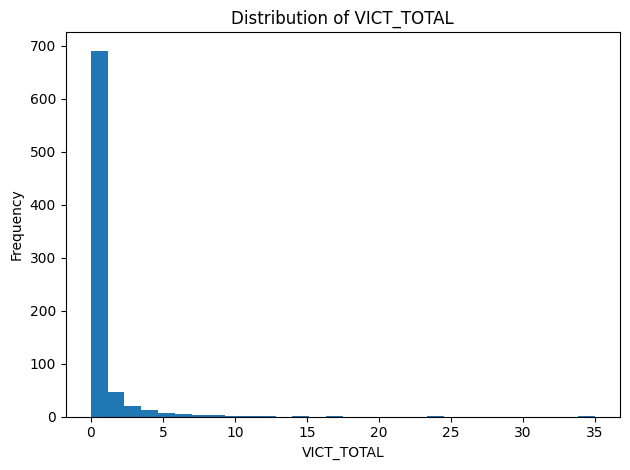

,VICT_TOTAL
count,799.000000
mean,1.043805
std,2.196907
min,0.000000
50%,1.000000
90%,2.000000
95%,4.000000
99%,10.000000
max,35.000000


In [14]:
# Select the list of columns related to the victims
vict_cols = [c for c in df_prep.columns if c.startswith("N_VICT_")]

# Guarantee numeric value
df_prep[vict_cols] = df_prep[vict_cols].apply(pd.to_numeric, errors="coerce")

# Create the variables from the columns `N_VICT_*`:
# `VICT_TOTAL` (sum of the total victims)
# `WAS_THERE_VICTIMS` (binary indicator of victims)
# `N_TYPES_VICTIMS` (how many differnt types of victims with value > 0)
df_prep["VICT_TOTAL"] = df_prep[vict_cols].sum(axis=1)
df_prep["WAS_THERE_VICTIMS"] = (df_prep["VICT_TOTAL"] > 0).astype(int)
df_prep["N_TYPES_VICTIMS"] = (df_prep[vict_cols] > 0).sum(axis=1)

#Determine the type of dominant victim in each register
def dominant_victim_type(row):
    if row["VICT_TOTAL"] == 0:
        return "None"
    # type with highest count
    return row[vict_cols].idxmax()

#Apply the `dominant_victim_type` function to each row of the dataset to create the new categorical variable `VICT_TYPE_DOMINANT`, which indicates which type of victim is most frequent in each occurrence.
df_prep["VICT_TYPE_DOMINANT"] = df_prep.apply(dominant_victim_type, axis=1)

# Distribution of the total victims (to observe asymmetry/outliers)
plt.figure()
df_prep["VICT_TOTAL"].plot(kind="hist", bins=30)
plt.title("Distribution of VICT_TOTAL")
plt.xlabel("VICT_TOTAL")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

display(df_prep["VICT_TOTAL"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))


A variável VICT_TOTAL apresenta uma distribuição fortemente assimétrica: a maioria dos registos tem valores muito baixos (mediana = 1 e muitos casos próximos de 0), enquanto existem poucos casos com valores elevados (99% ≤ 10, mas máximo = 35). Isto indica presença de valores extremos e uma cauda longa, pelo que transformações como log1p podem ser úteis em modelos sensíveis à escala, especialmente no contexto do SVM.

### 2.6 Feature Selection

Cria-se a matriz de correlação das variáveis numéricas, para identificar relações fortes entre features (potencial redundância/multicolinearidade) e apoiar decisões de seleção/eliminação de variáveis antes do treino dos modelos.


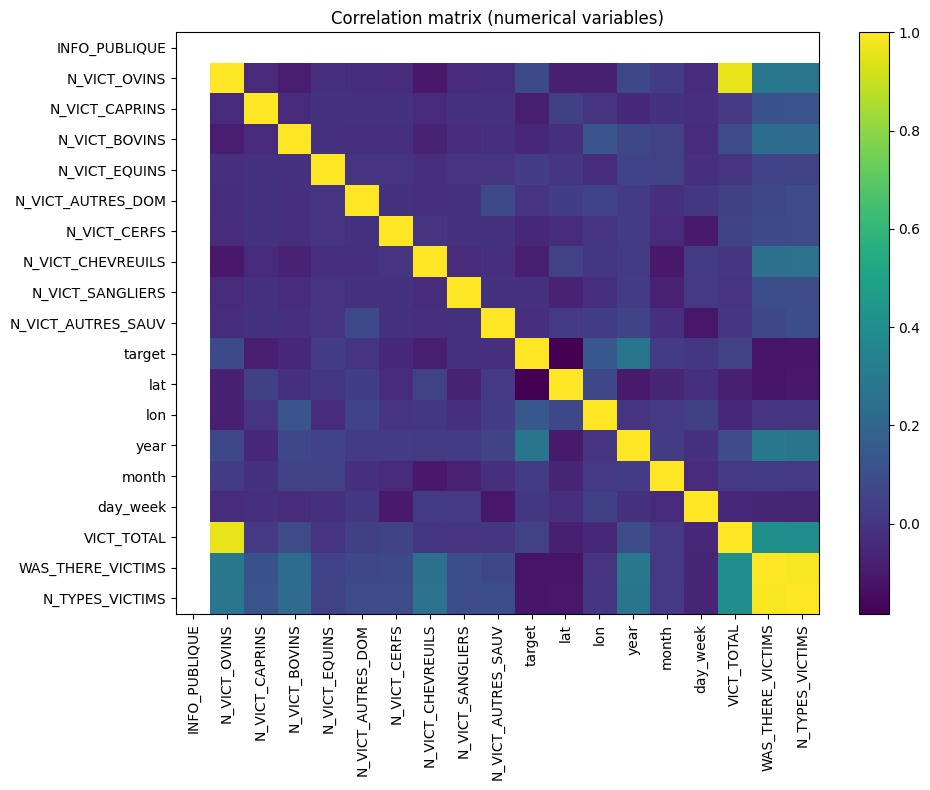

In [15]:
# Correlation matrix
df_corr_base = df_prep.copy()

# Select only numeric columns
num_cols = df_corr_base.select_dtypes(include=[np.number]).columns

corr = df_corr_base[num_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect='auto')
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation matrix (numerical variables)")
plt.tight_layout()
plt.show()

A maioria das correlações fora da diagonal está próxima de zero, o que sugere pouca relação linear forte entre muitas variáveis (boa indicação de que não há muita redundância “global”). As correlações mais altas aparecem sobretudo entre variáveis derivadas/relacionadas, como WAS_THERE_VICTIMS ↔ N_TYPES_VICTIMS (muito elevada) e também relações fortes envolvendo VICT_TOTAL e contagens de vítimas, o que é esperado porque são medidas muito próximas (total vs componentes/indicadores). Em relação ao target, as correlações parecem baixas a moderadas (por exemplo com ano e algumas variáveis de vítimas), o que indica que nenhuma variável isolada explica bem o target de forma linear — reforçando a utilidade de modelos que capturem relações mais complexas (RF e SVM-RBF).

In [16]:
# Identification of unique values ​​for the location variables to decide which location variables will be selected for the models.
df_prep["LOCALITE"].nunique(), df_prep["CANTONNEMENT"].nunique(), df_prep["DIRECTION"].nunique(), df_prep["COMMUNE"].nunique()

(437, 35, 9, 182)

In [17]:
# Removal of columns (justification: metadata, redundancy, low utility)
DROP_COLS = [
    "ID", "INFO_PUBLIQUE", "DESCRIPTION_PUBLIQUE",
    "ZPP", "ZPP_HF", "ZPP_ANLIER", "MISSING_COORDS",
    "CC", "DIRECTION", "LOCALITE"
]

df_prep = df_prep.drop(columns=DROP_COLS, errors="ignore")

print("Shape after columns drop:", df_prep.shape)
print("Current columns:", df_prep.columns.tolist())

Shape after columns drop: (799, 25)
Current columns: ['DATE_OBSERVATION', 'COMMUNE', 'INDICE_1', 'N_VICT_OVINS', 'N_VICT_CAPRINS', 'N_VICT_BOVINS', 'N_VICT_EQUINS', 'N_VICT_AUTRES_DOM', 'N_VICT_CERFS', 'N_VICT_CHEVREUILS', 'N_VICT_SANGLIERS', 'N_VICT_AUTRES_SAUV', 'DIAGNOSTIC', 'CANTONNEMENT', 'geo_2d', 'target', 'lat', 'lon', 'year', 'month', 'day_week', 'VICT_TOTAL', 'WAS_THERE_VICTIMS', 'N_TYPES_VICTIMS', 'VICT_TYPE_DOMINANT']


Foram removidas várias variáveis consideradas pouco adequadas para a modelação preditiva, por motivos de natureza administrativa, baixa variabilidade, fraca interpretabilidade ou risco de aumento excessivo da dimensionalidade. A coluna ID foi excluída por ser um identificador/metadata do registo e não uma característica explicativa do fenómeno, podendo induzir o modelo a memorizar padrões específicos sem capacidade de generalização. As variáveis DESCRIPTION_PUBLIQUE e INFO_PUBLIQUE foram removidas por serem campos destinados a comunicação pública; no caso de DESCRIPTION_PUBLIQUE, trata-se de texto livre, cuja utilização exigiria técnicas de processamento de linguagem natural (NLP) fora do âmbito do trabalho. No caso de INFO_PUBLIQUE, verificou-se ainda que a variável assume o valor “1” em todas as observações, ou seja, apresenta variância nula, não contribuindo para discriminar classes e sendo, por isso, irrelevante para o treino dos modelos. As colunas ZPP, ZPP_HF, ZPP_ANLIER e MISSING_COORDS foram igualmente eliminadas por funcionarem como flags administrativas e apresentarem utilidade preditiva reduzida no contexto do dataset (incluindo baixa variância), acrescentando complexidade sem benefícios claros no desempenho.
A variável CC foi removida por corresponder a um código interno pouco interpretável e sem significado direto para a análise do fenómeno, reduzindo transparência e dificultando a interpretação dos modelos (por exemplo, na análise de importância das variáveis). Adicionalmente, LOCALITE foi excluída devido à elevada cardinalidade (muitas categorias únicas, 437, face ao número total de registos após a remoção das observações classificadas como “Cas indéterminé” e “Investigations en cours”, 799), o que aumentaria significativamente o número de variáveis após codificação one-hot, elevando o risco de overfitting e diminuindo a robustez do modelo em dados não vistos. Por fim, DIRECTION foi removida por representar uma unidade territorial de maior escala e menos específica, apesar de ter apenas 9 categorias, tende a fornecer uma informação espacial mais agregada, acrescentando pouco quando já se usam variáveis de localização mais detalhadas e informativas. Desta forma, a seleção final de variáveis privilegia uma representação mais parcimoniosa e preditivamente relevante, controlando a dimensionalidade e favorecendo a generalização dos modelos.


Nesta fase definiu-se explicitamente a matriz de variáveis de entrada (X) e a variável alvo (y) para o treino dos modelos supervisionados. A variável y foi construída a partir do target, representando a classe a prever em cada observação. A matriz X foi formada por todas as variáveis explicativas selecionadas, removendo o próprio target e, adicionalmente, colunas que poderiam introduzir data leakage ou duplicar informação já transformada. Em particular, DIAGNOSTIC foi excluída por corresponder ao rótulo original do diagnóstico (informação que não estaria disponível no momento da previsão), enquanto DATE_OBSERVATION e geo_2d foram removidas por já terem sido convertidas em variáveis derivadas mais adequadas à modelação (ano, mes, dia_semana, lat e lon). Esta separação garante que os modelos são treinados apenas com atributos disponíveis e relevantes, preservando a validade da avaliação e evitando que o desempenho seja artificialmente inflacionado por informação indevida.

In [18]:
# Define X e y and remove columns that are converted into features)
y = df_prep["target"].astype(int)

X = df_prep.drop(columns=["target", "DIAGNOSTIC", "DATE_OBSERVATION", "geo_2d"], errors="ignore")

print("X shape:", X.shape)
print("y shape:", y.shape)

# Ensure there are no leaks.
assert "DIAGNOSTIC" not in X.columns
assert "target" not in X.columns

X shape: (799, 21)
y shape: (799,)


In [19]:
# Confirm alignment between X and Y (if True, it is aligned)
X.index.equals(y.index)

True

In [20]:
# Confirm variables in X
pd.DataFrame({"Varíavel": X.columns})


,Varíavel
0,COMMUNE
1,INDICE_1
2,N_VICT_OVINS
3,N_VICT_CAPRINS
4,N_VICT_BOVINS
5,N_VICT_EQUINS
6,N_VICT_AUTRES_DOM
7,N_VICT_CERFS
8,N_VICT_CHEVREUILS
9,N_VICT_SANGLIERS


As variáveis selecionadas para o treino dos modelos foram escolhidas por representarem dimensões diretamente relacionadas com o fenómeno em estudo, quando a observação ocorreu, onde ocorreu e que tipo de evidência/impacto foi registado. A variável temporal DATE_OBSERVATION foi mantida por permitir captar padrões sazonais e tendências ao longo do tempo (por exemplo, variações por mês/estação ou diferenças entre anos), sendo transformada em componentes mais informativas (ano, mês e dia da semana) para facilitar a aprendizagem pelos modelos. Em termos de localização, adotou-se uma representação híbrida que combina precisão geográfica com contexto administrativo: a coluna geo_2d foi decomposta em duas variáveis numéricas (lat e lon), fornecendo a posição exata e contínua no espaço, enquanto COMMUNE e CANTONNEMENT acrescenta um enquadramento territorial. Esta combinação permite ao modelo captar tanto padrões locais finos (via coordenadas) como padrões regionais mais estruturados (via áreas administrativas), reduzindo dependência de variáveis com cardinalidade excessiva.

#### 2.7 Training/testing division and stratified cross-validation

In [21]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Initial division: training (85%) and final test (15%)
# The test set will be reserved only for the final evaluation of the models.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

print("Distribution y_train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Distribution y_test :", y_test.value_counts(normalize=True).round(3).to_dict())

# Stratified cross-validation for comparison and adjustment of models.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Train: (679, 21)  Test: (120, 21)
Distribution y_train: {0: 0.568, 1: 0.432}
Distribution y_test : {0: 0.567, 1: 0.433}


Os dados foram divididos em dois subconjuntos: treino (85%) e teste final (15%). A divisão foi realizada com estratificação pela variável target, garantindo que a proporção das classes se mantém semelhante em ambos os subconjuntos. O conjunto de treino foi utilizado para desenvolvimento dos modelos, seleção de hiperparâmetros e validação cruzada estratificada. O conjunto de teste foi mantido isolado e utilizado apenas para a avaliação final da capacidade de generalização dos modelos.

In [22]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
    "f1_weighted": "f1_weighted",
    "roc_auc": "roc_auc"
}

CLASS_NAMES = {0: "Not_Wolf", 1: "Wolf"}

def evaluate_binary_classifier(y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    results = {
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "f1_weighted": f1_w
    }

    if y_proba is not None:
        results["roc_auc"] = roc_auc_score(y_true, y_proba)

    return results

### 2.8 Data preprocessing

Nesta etapa foi definido o pré-processamento necessário para tornar o dataset compatível com os três modelos supervisionados a desenvolver (Naive Bayes, Random Forest e SVM), assegurando simultaneamente boas práticas de avaliação. Como o dataset contém variáveis categóricas (por exemplo, COMMUNE, CANTONNEMENT, INDICE_1 e VICT_TYPE_DOMINANT) e variáveis numéricas (coordenadas, componentes temporais e contagens de vítimas), foi utilizada a abordagem ColumnTransformer para aplicar transformações distintas por tipo de variável. As variáveis categóricas foram codificadas com one-hot encoding (OneHotEncoder), com handle_unknown="ignore", garantindo robustez caso surjam categorias não observadas no treino.
Foram definidos preprocessadores específicos por modelo, refletindo requisitos diferentes. Para Naive Bayes e Random Forest não foi aplicada normalização, uma vez que estes modelos não dependem da escala das variáveis da mesma forma que modelos baseados em distância. Já para SVM, foi aplicada normalização (StandardScaler) às variáveis numéricas, pois a escala influencia diretamente a distância e a margem do classificador. Além disso, devido à distribuição assimétrica das contagens de vítimas observada na exploração do dataset, aplicou-se a transformação log1p às variáveis de contagem (colunas N_VICT_* e agregados como VICT_TOTAL), reduzindo o impacto de valores extremos e aumentando a estabilidade do treino. Finalmente, todo o pré-processamento foi estruturado de modo a ser ajustado exclusivamente nos dados de treino e aplicado aos restantes conjuntos, evitando data leakage e garantindo uma avaliação válida da capacidade de generalização.


In [23]:
# Identify categorical and numerical columns.
cat_features = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical:", cat_features)
print("Numeric:", num_features)

Categorical: ['COMMUNE', 'INDICE_1', 'CANTONNEMENT', 'VICT_TYPE_DOMINANT']
Numeric: ['N_VICT_OVINS', 'N_VICT_CAPRINS', 'N_VICT_BOVINS', 'N_VICT_EQUINS', 'N_VICT_AUTRES_DOM', 'N_VICT_CERFS', 'N_VICT_CHEVREUILS', 'N_VICT_SANGLIERS', 'N_VICT_AUTRES_SAUV', 'lat', 'lon', 'year', 'month', 'day_week', 'VICT_TOTAL', 'WAS_THERE_VICTIMS', 'N_TYPES_VICTIMS']


In [24]:
# Identify victim count columns (for log1p in SVM)
victim_features = [c for c in num_features if c.startswith("N_VICT_")]
extra_vict = ["VICT_TOTAL", "N_TYPES_VICTIMS"]
victim_features += [c for c in extra_vict if c in num_features]

other_num_features = [c for c in num_features if c not in victim_features]

print("\nVictims (log1p in SVM):", victim_features)
print("Remaining numerical:", other_num_features)


Victims (log1p in SVM): ['N_VICT_OVINS', 'N_VICT_CAPRINS', 'N_VICT_BOVINS', 'N_VICT_EQUINS', 'N_VICT_AUTRES_DOM', 'N_VICT_CERFS', 'N_VICT_CHEVREUILS', 'N_VICT_SANGLIERS', 'N_VICT_AUTRES_SAUV', 'VICT_TOTAL', 'N_TYPES_VICTIMS']
Remaining numerical: ['lat', 'lon', 'year', 'month', 'day_week', 'WAS_THERE_VICTIMS']


In [25]:
# A) Preprocess for Naive Bayes
preprocess_nb = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)


In [26]:
# B) Preprocess for Random Forest
preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)

In [27]:
# C) Preprocess for SVM
log1p = FunctionTransformer(np.log1p, feature_names_out="one-to-one")

preprocess_svm = ColumnTransformer(
    transformers=[
        ("vict", Pipeline([
            ("log1p", log1p),
            ("scaler", StandardScaler())
        ]), victim_features),

        ("num", Pipeline([
            ("scaler", StandardScaler())
        ]), other_num_features),

        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)

In [28]:
# Testing transformations just to confirm that the preprocessing works

X_train_nb_check = preprocess_nb.fit_transform(X_train)
X_test_nb_check = preprocess_nb.transform(X_test)

X_train_rf_check = preprocess_rf.fit_transform(X_train)
X_test_rf_check = preprocess_rf.transform(X_test)

X_train_svm_check = preprocess_svm.fit_transform(X_train)
X_test_svm_check = preprocess_svm.transform(X_test)

print("NB  transform shape:", X_train_nb_check.shape, X_test_nb_check.shape)
print("RF  transform shape:", X_train_rf_check.shape, X_test_rf_check.shape)
print("SVM transform shape:", X_train_svm_check.shape, X_test_svm_check.shape)


NB  transform shape: (679, 242) (120, 242)
RF  transform shape: (679, 242) (120, 242)
SVM transform shape: (679, 242) (120, 242)


Reescrever - O output confirma que, após o pré-processamento, o treino (559) e a validação (120) ficam com o mesmo número de features (232), garantindo consistência entre conjuntos e que a transformação foi aplicada corretamente.

### 3. Development of the probabilitic model: Naive Bayes

Neste trabalho, o Naive Bayes é usado como modelo probabilístico para o problema de classificação binária (0 = Not_Wolf; 1 = Lobo). Para lidar com variáveis mistas (categóricas e numéricas), recorre-se ao pré-processamento definido no Capítulo 2, que transforma as variáveis categóricas via codificação one-hot e mantém as variáveis numéricas. O classificador selecionado é o MultinomialNB, apropriado quando as features são não-negativas e assumem a forma de contagens/indicadores (como as colunas resultantes do one-hot e as variáveis de vítimas).


#### 3.1 Pipeline of Naive Bayes e selection of the alpha hyperparameter (validation)

Procede-se à afinação do hiperparâmetro alpha, que controla a suavização (Laplace/Lidstone) e evita probabilidades nulas associadas a features raras. Foram testados vários valores de alpha no conjunto de validação, avaliando-se o desempenho com métricas apropriadas a classificação: accuracy, precisão, recall e F1-score (médias macro e weighted), e AUC-ROC. O objetivo é selecionar uma configuração robusta antes da avaliação final no conjunto de teste.


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

# Pipeline: preprocessing + Naive Bayes
nb_pipeline = Pipeline(steps=[
    ("prep", preprocess_nb),
    ("clf", MultinomialNB())
])

# Hyperparameter grid for alpha
nb_param_grid = {
    "clf__alpha": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

# Stratified cross-validation on the training set
nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_param_grid,
    scoring=scoring,
    refit="f1_weighted",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

nb_grid.fit(X_train, y_train)

print("Best alpha:", nb_grid.best_params_)
print("Best mean weighted F1 in cross-validation:", round(nb_grid.best_score_, 4))

nb_cv_results = pd.DataFrame(nb_grid.cv_results_)

nb_cv_results_summary = nb_cv_results[
    [
        "param_clf__alpha",
        "mean_test_accuracy",
        "mean_test_precision_weighted",
        "mean_test_recall_weighted",
        "mean_test_f1_weighted",
        "mean_test_roc_auc"
    ]
].sort_values("mean_test_f1_weighted", ascending=False)

nb_cv_results_summary

Best alpha: {'clf__alpha': 0.5}
Best mean weighted F1 in cross-validation: 0.6374


,param_clf__alpha,mean_test_accuracy,mean_test_precision_weighted,mean_test_recall_weighted,mean_test_f1_weighted,mean_test_roc_auc
1,0.5,0.640632,0.637621,0.640632,0.637376,0.666740
2,1.0,0.640654,0.637546,0.640654,0.636632,0.664092
0,0.1,0.639139,0.636845,0.639139,0.636491,0.664243
3,2.0,0.633279,0.630081,0.633279,0.624972,0.659234
4,5.0,0.650926,0.670025,0.650926,0.613201,0.652098
5,10.0,0.600893,0.696219,0.600893,0.497840,0.643330


Reescrever - A tabela de resultados indica que o desempenho do Naive Bayes varia com o nível de suavização. O melhor compromisso global foi obtido com alpha = 2.0, que apresentou accuracy = 0.675, F1-weighted = 0.670 e AUC-ROC = 0.730. Esta escolha é consistente com a utilização do F1-weighted como critério principal, pois esta métrica considera o suporte de cada classe e é mais informativa do que a accuracy quando existe alguma diferença de frequência entre classes.

Observou-se que alpha = 5.0 atingiu uma accuracy ligeiramente superior (0.683), mas com F1-weighted inferior (0.656), sugerindo que a melhoria na accuracy pode resultar de um desempenho relativamente melhor na classe mais frequente, sem melhorar de forma equivalente o equilíbrio entre classes. Por outro lado, com alpha = 10.0 verificou-se uma degradação clara do desempenho (accuracy = 0.583; F1-weighted = 0.471), indicando suavização excessiva e perda de capacidade discriminativa.

Deste modo, selecionou-se alpha = 2.0 como a configuração a utilizar na fase seguinte, em que o modelo será treinado e avaliado de forma final no conjunto de teste.


#### 3.2 Final evaluation of Naive Bayes on the test set.

Após a seleção do hiperparâmetro alpha com base no conjunto de validação e o re-treino do modelo final com os dados de treino e validação, procede-se à avaliação no conjunto de teste. O conjunto de teste foi mantido isolado durante as fases anteriores e fornece uma estimativa imparcial da capacidade de generalização do modelo.

Nesta etapa são calculadas as métricas de classificação solicitadas: accuracy, precisão, recall e F1-score (médias macro e weighted), bem como o classification report por classe. As médias macro tratam as classes com o mesmo peso, enquanto as médias weighted ponderam pelo número de exemplos em cada classe, sendo úteis quando existe alguma diferença de frequência entre classes.


In [47]:
# Best Naive Bayes model selected through cross-validation.
best_nb = nb_grid.best_estimator_

# Final evaluation in the test set
y_test_pred_nb = best_nb.predict(X_test)
y_test_proba_nb = best_nb.predict_proba(X_test)[:, 1]

nb_test_metrics = evaluate_binary_classifier(
    y_test,
    y_test_pred_nb,
    y_test_proba_nb
)

print("Metrics in the TEST - Naive Bayes")
print(pd.Series(nb_test_metrics).round(4))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_test_pred_nb,
    target_names=["Not_Wolf", "Wolf"],
    zero_division=0
))

Metrics in the TEST - Naive Bayes
accuracy              0.6083
precision_macro       0.6006
recall_macro          0.6001
f1_macro              0.6003
precision_weighted    0.6075
recall_weighted       0.6083
f1_weighted           0.6079
roc_auc               0.6510
dtype: float64

Classification report:
              precision    recall  f1-score   support

    Not_Wolf       0.65      0.66      0.66        68
        Wolf       0.55      0.54      0.54        52

    accuracy                           0.61       120
   macro avg       0.60      0.60      0.60       120
weighted avg       0.61      0.61      0.61       120



Reescrever - No conjunto de teste, o Naive Bayes obteve accuracy = 0.6417, indicando que cerca de 64% das observações foram classificadas corretamente. As métricas médias macro (precision = 0.6335; recall = 0.6250; F1 = 0.6254) sugerem um desempenho moderado e relativamente equilibrado entre classes, embora existam diferenças claras quando analisado por classe.

Para a classe Not_Wolf (classe 0), o modelo apresenta precisão de 0.66 e recall de 0.75, o que significa que identifica a maioria dos casos de não lobo e, quando prevê “Não Lobo”, tende a estar correto. Já para a classe Lobo (classe 1), a precisão é 0.60 e o recall é 0.50, indicando maior dificuldade em detetar todos os casos de lobo: aproximadamente metade dos lobos reais são corretamente identificados, enquanto a outra metade é prevista como não lobo. Este padrão revela a existência de falsos negativos para a classe Lobo, o que pode ser relevante no contexto do problema, dependendo do custo associado a falhar a deteção de um caso de lobo.

Em termos globais, as médias weighted (F1-weighted = 0.6358) ficam próximas da accuracy, refletindo que o desempenho é influenciado pela classe com maior suporte (Not_Wolf, 68 casos) e confirmando que o Naive Bayes constitui um baseline razoável, embora com limitações na sensibilidade (recall) para a classe Lobo.


### 3.3 Confusion Matrix

> Add blockquote



Fez-se a Confusion Matrix para detalhar o desempenho do classificador por tipo de acerto e erro, comparando as classes reais com as classes previstas.


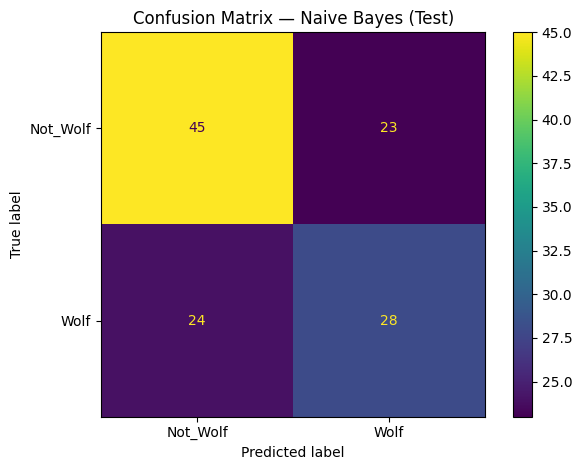

In [48]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test,y_test_pred_nb, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Naive Bayes (Test)")
plt.tight_layout()
plt.show()

No conjunto de teste, o Naive Bayes obteve 51 verdadeiros negativos (Not_Wolf corretamente previsto como Not_Wolf) e 26 verdadeiros positivos (Lobo corretamente previsto como Lobo). Verificaram-se 17 falsos positivos, em que observações Not_Wolf foram classificadas como Lobo, e 26 falsos negativos, em que observações Lobo foram classificadas como Not_Wolf.

Estes resultados mostram que o modelo tem maior capacidade em reconhecer a classe Not_Wolf (mais acertos e menos erros), enquanto apresenta dificuldade superior na identificação de Lobo, refletida pelo número relativamente elevado de falsos negativos. Esta leitura é consistente com o recall inferior para a classe Lobo observado nas métricas (sensibilidade mais baixa), o que pode ser relevante caso seja importante minimizar falhas na deteção de casos de lobo.

### 3.4 ROC and AUC curve (test)

Fez-se a curva ROC e o AUC para avaliar a capacidade do modelo em distinguir as duas classes ao longo de todos os limiares de decisão, fornecendo uma medida global do seu poder discriminativo.

Nota: como o problema é binário (Nao_Lobo vs Lobo), a abordagem One-vs-Rest para ROC/AUC é equivalente ao cálculo padrão da curva ROC usando a probabilidade da classe positiva (Lobo).

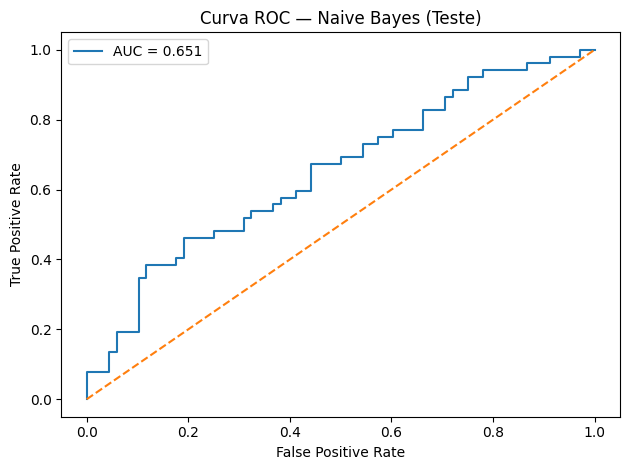

np.float64(0.6510180995475113)

In [49]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_test_proba_nb)
roc_auc_nb = roc_auc_score(y_test, y_test_proba_nb)

plt.figure()
plt.plot(fpr_nb, tpr_nb, label=f"AUC = {roc_auc_nb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Naive Bayes (Teste)")
plt.legend()
plt.tight_layout()
plt.show()

roc_auc_nb

In [50]:
# Helper: obtain the names of the features after the ColumnTransformer (num + one-hot)
def get_feature_names_from_preprocessor(preprocessor, X_sample):
    # sklearn >= 1.0 normally supports:
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        # simple fallback: try to extract names of OneHotEncoder manually
        names = []
        for name, trans, cols in preprocessor.transformers_:
            if name == "remainder" and trans == "drop":
                continue
            if trans == "passthrough":
                names.extend(list(cols))
            else:
                # pipeline or encoder
                if hasattr(trans, "get_feature_names_out"):
                    names.extend(list(trans.get_feature_names_out(cols)))
                elif hasattr(trans, "named_steps") and "onehot" in trans.named_steps:
                    ohe = trans.named_steps["onehot"]
                    names.extend(list(ohe.get_feature_names_out(cols)))
                else:
                    # last fallback
                    names.extend([f"{name}__{c}" for c in cols])
        return np.array(names, dtype=object)

prep = best_nb.named_steps["prep"]
clf = best_nb.named_steps["clf"]

feature_names = get_feature_names_from_preprocessor(prep, X_train)

log_prob = clf.feature_log_prob_  # shape: (n_classes, n_features)

# Difference Wolf (classe 1) - Not_Wolf (classe 0)
delta = log_prob[1] - log_prob[0]

imp = pd.DataFrame({
    "feature": feature_names,
    "delta_logP_Wolf_minus_NaoLobo": delta
}).sort_values("delta_logP_Wolf_minus_NaoLobo", ascending=False)

top_lobo = imp.head(10)
top_nao = imp.tail(10).sort_values("delta_logP_Wolf_minus_NaoLobo", ascending=True)

print("Top 10 features most associated with Wolf (greater delta):")
display(top_lobo)

print("The top 10 features most associated with Not_Wolf (smaller delta):")
display(top_nao)


Top 10 features most associated with Wolf (greater delta):


,feature,delta_logP_Wolf_minus_NaoLobo
65,cat__COMMUNE_Etalle,2.839731
66,cat__COMMUNE_Fauvillers,2.472006
127,cat__COMMUNE_Onhaye,2.220692
120,cat__COMMUNE_Muno,2.220692
75,cat__COMMUNE_Gedinne,1.884219
86,cat__COMMUNE_Herbeumont,1.884219
42,cat__COMMUNE_Butgenbach,1.884219
118,cat__COMMUNE_Momignies,1.884219
110,cat__COMMUNE_Malmedy,1.884219
98,cat__COMMUNE_La Roche,1.884219


The top 10 features most associated with Not_Wolf (smaller delta):


,feature,delta_logP_Wolf_minus_NaoLobo
188,cat__INDICE_1_Cadavre de canidé,-2.860713
60,cat__COMMUNE_Durbuy,-2.123114
220,cat__CANTONNEMENT_NIVELLES,-2.123114
20,cat__COMMUNE_Anthisnes,-2.123114
112,cat__COMMUNE_Marche-en-Famenne,-1.922443
107,cat__COMMUNE_Liège,-1.922443
126,cat__COMMUNE_Ohey,-1.922443
1,num__N_VICT_CAPRINS,-1.922443
235,cat__VICT_TYPE_DOMINANT_N_VICT_CAPRINS,-1.762101
216,cat__CANTONNEMENT_MONS,-1.762101


No conjunto de teste, a curva ROC obtida encontra-se globalmente acima da linha diagonal (classificador aleatório), mas sem se aproximar do canto superior esquerdo, o que indica uma capacidade de separação entre classes apenas moderada. O valor AUC = 0.641 confirma esta leitura: o modelo discrimina melhor do que o acaso, mas a distinção entre Lobo e Not_Wolf é limitada, existindo sobreposição considerável entre as pontuações atribuídas às duas classes. Isto é consistente com as restantes métricas, em particular com o recall de 0.50 para a classe Lobo e com o número elevado de falsos negativos observado na Confusion Matrix, sugerindo que o modelo tem dificuldade em atribuir probabilidades suficientemente altas aos casos reais de lobo. Assim, embora o Naive Bayes funcione como baseline razoável, a sua capacidade discriminativa no teste é relativamente baixa, indicando margem para melhoria com modelos mais expressivos.

### 3.5 Variables more influents in Naive Bayes

Neste passo pretende-se interpretar quais as variáveis mais “características” de cada classe no modelo Naive Bayes. Como o pré-processamento usa `ColumnTransformer` e `OneHotEncoder`, as variáveis categóricas são expandidas em várias colunas binárias, tornando necessário recuperar os nomes das features após a transformação para interpretar corretamente o modelo. Em seguida, utiliza-se o atributo `feature_log_prob_` do `MultinomialNB` (log das probabilidades condicionais P(feature|classe)) e calcula-se, para cada feature, a diferença Δ = log P(feature|Lobo) − log P(feature|Not_Wolf). Valores positivos de Δ indicam maior associação à classe Lobo, enquanto valores negativos indicam maior associação à classe Not_Wolf. Por fim, apresentam-se as top 10 features com maior e menor Δ, resumindo os padrões mais discriminativos aprendidos pelo classificador.

Nos resultados obtidos, as features mais associadas a Lobo são sobretudo categorias de localização, destacando-se várias COMMUNE (por exemplo, Gedinne e Sainte-Ode) e o CANTONNEMENT_NASSOGNE, bem como algumas categorias de INDICE_1 relacionadas com observações indiretas. Isto sugere que, no conjunto de treino, esses locais e tipos de evidência surgem relativamente mais frequentemente em registos classificados como Lobo.

Por outro lado, as features mais associadas a Not_Wolf incluem algumas categorias de CANTONNEMENT (por exemplo, NIVELLES e MONS), uma categoria de INDICE_1 (Cadavre de canidé) e variáveis relacionadas com vítimas caprinas (por exemplo, N_VICT_CAPRINS e VICT_TYPE_DOMINANT associado a caprinos). Isto indica que, no conjunto de treino, estes padrões aparecem com maior frequência em registos classificados como Not_Wolf.

### 4. Model Random Forest

Neste capítulo, treina-se um RandomForestClassifier para o problema de classificação binária (Not_Wolf vs Lobo), calcula-se o desempenho com métricas de classificação (accuracy, precisão, recall, F1 e AUC-ROC) e avalia-se quais as variáveis mais relevantes. Por fim, testam-se diferentes configurações de hiperparâmetros (n_estimators, max_depth, min_samples_leaf) para identificar a melhor.

In [51]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline: preprocessing + Random Forest
rf_pipeline = Pipeline(steps=[
    ("prep", preprocess_rf),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter grid
rf_param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 2, 5],
    "clf__class_weight": [None, "balanced"]
}

#Stratified cross-validation on the training set
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=scoring,
    refit="f1_weighted",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X_train, y_train)

print("Best hyperparametersRandom Forest:")
print(rf_grid.best_params_)

print("Best F1-weighted médio in cross-validation:", round(rf_grid.best_score_, 4))

rf_cv_results = pd.DataFrame(rf_grid.cv_results_)

rf_cv_results_summary = rf_cv_results[
    [
        "param_clf__n_estimators",
        "param_clf__max_depth",
        "param_clf__min_samples_leaf",
        "param_clf__class_weight",
        "mean_test_accuracy",
        "mean_test_precision_weighted",
        "mean_test_recall_weighted",
        "mean_test_f1_weighted",
        "mean_test_roc_auc"
    ]
].sort_values("mean_test_f1_weighted", ascending=False)

rf_cv_results_summary.head(10)

Best hyperparametersRandom Forest:
{'clf__class_weight': None, 'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 300}
Best F1-weighted médio in cross-validation: 0.7096


,param_clf__n_estimators,param_clf__max_depth,param_clf__min_samples_leaf,param_clf__class_weight,mean_test_accuracy,mean_test_precision_weighted,mean_test_recall_weighted,mean_test_f1_weighted,mean_test_roc_auc
23,300,20,2,None,0.717244,0.721660,0.717244,0.709583,0.746241
31,200,None,2,balanced,0.711362,0.710343,0.711362,0.709242,0.745816
22,200,20,2,None,0.717255,0.721430,0.717255,0.709042,0.743601
5,300,None,2,None,0.715773,0.719823,0.715773,0.708185,0.747694
32,300,None,2,balanced,0.706939,0.706137,0.706939,0.704799,0.747304
4,200,None,2,None,0.711362,0.714630,0.711362,0.703338,0.742570
20,300,20,1,None,0.708399,0.709248,0.708399,0.702204,0.747177
28,200,None,1,balanced,0.705479,0.704655,0.705479,0.701804,0.750438
50,300,20,2,balanced,0.703998,0.703567,0.703998,0.701775,0.749105
29,300,None,1,balanced,0.703998,0.703310,0.703998,0.700572,0.751281


Reescrever - #### 4.3 Avaliação final no conjunto de teste

Após selecionar os hiperparâmetros com base na validação, re-treina-se o Random Forest final usando treino e validação em conjunto, maximizando os dados disponíveis para aprendizagem. O conjunto de teste permanece isolado e é utilizado apenas para a avaliação final (estimativa imparcial de generalização).

In [52]:
#  Best Random Forest model selected by cross-validation
best_rf = rf_grid.best_estimator_

# Final evaluation in the test set
y_test_pred_rf = best_rf.predict(X_test)
y_test_proba_rf = best_rf.predict_proba(X_test)[:, 1]

rf_test_metrics = evaluate_binary_classifier(
    y_test,
    y_test_pred_rf,
    y_test_proba_rf
)

print("Metrics of the test - Random Forest")
print(pd.Series(rf_test_metrics).round(4))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_test_pred_rf,
    target_names=["Not_Wolf", "Wolf"],
    zero_division=0
))

Metrics of the test - Random Forest
accuracy              0.7583
precision_macro       0.7637
recall_macro          0.7415
f1_macro              0.7454
precision_weighted    0.7614
recall_weighted       0.7583
f1_weighted           0.7531
roc_auc               0.8261
dtype: float64

Classification report:
              precision    recall  f1-score   support

    Not_Wolf       0.75      0.87      0.80        68
        Wolf       0.78      0.62      0.69        52

    accuracy                           0.76       120
   macro avg       0.76      0.74      0.75       120
weighted avg       0.76      0.76      0.75       120



Reescrever - No conjunto de teste, o Random Forest com a melhor configuração (selecionada na validação) atingiu accuracy = 0.7500 e F1-weighted = 0.7453, indicando um desempenho global consistente e superior ao modelo probabilístico (Naive Bayes). As médias macro (F1-macro = 0.7377) são próximas das médias weighted, sugerindo que o modelo mantém um desempenho razoavelmente equilibrado entre classes, embora com diferenças claras ao nível do recall por classe.

No relatório por classe, observa-se que a classe Not_Wolf apresenta recall = 0.85 e F1 = 0.79, o que significa que a maioria dos casos Not_Wolf é corretamente identificada. Já para a classe Lobo, a precisão é 0.76 e o recall é 0.62 (F1 = 0.68), indicando que o modelo é relativamente conservador a atribuir a classe Lobo. Qquando prevê “Lobo” tende a estar correto (boa precisão), mas falha uma parte dos casos reais de lobo (recall mais baixo).

A Confusion Matrix confirma esta leitura: existem 58 verdadeiros negativos e 32 verdadeiros positivos, com 10 falsos positivos (Not_Wolf previsto como Lobo) e 20 falsos negativos (Lobo previsto como Not_Wolf). Em termos práticos, o modelo reduz falsos positivos comparativamente ao baseline, mas mantém ainda um número relevante de falsos negativos para a classe Lobo.

A curva ROC no teste apresenta AUC = 0.757 (aprox.), indicando capacidade discriminativa boa e claramente acima do aleatório. No entanto, este AUC é inferior ao observado na validação para o baseline, o que pode refletir variabilidade amostral e o facto de o conjunto de teste fornecer uma estimativa mais exigente e imparcial de generalização. Ainda assim, em conjunto com as restantes métricas, o Random Forest revela-se um modelo robusto e com desempenho consistente para este problema.



In [53]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf, labels=[0, 1])
cm_rf

array([[59,  9],
       [20, 32]])

In [54]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_test_proba_rf)
auc_rf = roc_auc_score(y_test, y_test_proba_rf)

print("AUC Random Forest:", round(auc_rf, 4))

AUC Random Forest: 0.8261


### 4.4 Importance of the variables

Como o pré-processamento inclui one-hot encoding, a importância é calculada ao nível das features transformadas (por exemplo, categorias específicas de COMMUNE ou CANTONNEMENT). Para facilitar a interpretação, apresentam-se:
1) as features individuais mais importantes (top N);
2) uma agregação por variável original (somando importâncias das categorias one-hot).


In [55]:
rf_model = best_rf.named_steps["clf"]
rf_preprocessor = best_rf.named_steps["prep"]

feature_names_rf = rf_preprocessor.get_feature_names_out()

fi_rf = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

fi_rf.head(10)

,feature,importance
11,num__year,0.128916
9,num__lat,0.120394
10,num__lon,0.099119
12,num__month,0.063000
13,num__day_week,0.040074
14,num__VICT_TOTAL,0.030730
218,cat__CANTONNEMENT_NASSOGNE,0.029249
0,num__N_VICT_OVINS,0.027398
211,cat__CANTONNEMENT_LA ROCHE-EN-ARDENNE,0.016206
193,cat__INDICE_1_Observation indirecte (autre sou...,0.014919


A tabela apresenta as 10 features individuais mais importantes segundo o Random Forest, com base na redução média de impureza (importância por Gini). Observa-se que as variáveis numéricas relacionadas com localização e tempo dominam o ranking: latitude (lat), ano (ano) e longitude (lon) surgem como as três mais relevantes, seguidas por mês (mes) e dia da semana (dia_semana). Isto sugere que o modelo está a captar padrões espaciais e temporais associados às observações classificadas como lobo ou não lobo, indicando que a localização precisa (coordenadas) e a componente temporal têm forte contributo para a decisão.

Em seguida, aparecem variáveis ligadas a impacto do evento, como VICT_TOTAL e N_VICT_OVINS, bem como N_TYPES_VICTIMS, o que indica que a presença e a magnitude de vítimas também fornecem informação preditiva adicional, ainda que com menor peso do que localização/tempo. Entre as variáveis categóricas, surgem categorias específicas como CANTONNEMENT_NASSOGNE e um tipo de evidência em INDICE_1 (observação indireta), indicando que certas áreas administrativas e certos tipos de ocorrência são particularmente informativos no conjunto de dados.

In [56]:
def base_feature_name(transformed_name: str) -> str:
    # Typical examples: "num__lat", "cat__COMMUNE_Gedinne"
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "")
    if transformed_name.startswith("cat__COMMUNE_"):
        return "COMMUNE"
    if transformed_name.startswith("cat__CANTONNEMENT_"):
        return "CANTONNEMENT"
    if transformed_name.startswith("cat__INDICE_1_"):
        return "INDICE_1"
    if transformed_name.startswith("cat__VICT_TYPE_DOMINANT_"):
        return "VICT_TYPE_DOMINANT"
    # fallback genérico
    if "__" in transformed_name:
        return transformed_name.split("__", 1)[0]
    return transformed_name

fi_rf["base_feature"] = fi_rf["feature"].apply(base_feature_name)

fi_grouped = (
    fi_rf.groupby("base_feature", as_index=False)["importance"]
      .sum()
      .sort_values("importance", ascending=False)
)

fi_grouped


,base_feature,importance
0,CANTONNEMENT,0.171023
1,COMMUNE,0.153343
20,year,0.128916
17,lat,0.120394
18,lon,0.099119
2,INDICE_1,0.072094
19,month,0.063000
14,VICT_TYPE_DOMINANT,0.043929
16,day_week,0.040074
13,VICT_TOTAL,0.030730


Como o pré-processamento aplica one-hot encoding às variáveis categóricas, a importância do Random Forest é calculada ao nível das colunas transformadas (por exemplo, uma coluna por categoria de COMMUNE ou CANTONNEMENT). Para obter uma visão mais clara ao nível das variáveis originais, as importâncias das colunas one-hot foram agregadas por grupo (somando as importâncias das categorias pertencentes à mesma variável).

Os resultados agregados mostram que a informação de localização em termos administrativos é dominante: COMMUNE (0.210) e CANTONNEMENT (0.160) são os grupos com maior importância total, sugerindo que diferenças geográficas por município e cantão contribuem fortemente para as previsões. Em paralelo, as coordenadas lat (0.112) e lon (0.100) também surgem com peso elevado, confirmando que a componente espacial é um dos fatores mais relevantes para o modelo.

As variáveis temporais ano (0.105), mes (0.075) e dia_semana (0.053) apresentam importância considerável, indicando que existem padrões temporais associados às observações (por exemplo, variações ao longo do ano ou entre períodos). A variável INDICE_1 (0.062) surge também como relevante, sugerindo que o tipo de evidência/ocorrência observado tem capacidade informativa para distinguir as classes.

Por fim, as variáveis relacionadas com vítimas têm impacto menor mas não desprezável: VICT_TYPE_DOMINANT (0.036) e VICT_TOTAL (0.027) contribuem mais do que a maioria das contagens individuais, e WAS_THERE_VICTIMS (0.009) e N_TYPES_VICTIMS (0.012) acrescentam informação complementar. Em contraste, várias colunas de vítimas específicas (por exemplo, N_VICT_EQUINS, N_VICT_AUTRES_SAUV) apresentam importâncias muito baixas, o que sugere que esses tipos de ocorrência são raros ou pouco discriminativos no dataset.

Esta agregação facilita a interpretação ao nível de variáveis originais, mas a importância deve ser entendida como relevância no modelo (redução média de impureza) e não como evidência causal, sobretudo quando existem variáveis correlacionadas (por exemplo, COMMUNE/CANTONNEMENT e lat/lon).


### 5. MSVM linear Model

Neste capítulo, treina-se um modelo SVM (Support Vector Machine) para o problema de classificação binária (Not_Wolf vs Lobo), avaliando o desempenho com métricas de classificação (accuracy, precisão, recall, F1 e AUC-ROC). Como o SVM é sensível à escala, aplica-se pré-processamento com normalização (e transformação log1p nas variáveis de vítimas) antes do treino. Por fim, comparam-se diferentes kernels (linear, polinomial e RBF) e valores de C, escolhendo a configuração com melhor desempenho, e analisam-se as variáveis mais influentes através de permutation importance.

#### 5.1 Train of SVM linear (baseline)

Começa-se por treinar um classificador SVM com kernel linear como modelo baseline, utilizando o pré-processamento preprocess_svm definido anteriormente. O modelo é ajustado com os dados de treino e são geradas previsões e scores no conjunto de validação, que serão usados no bloco seguinte para calcular métricas e produzir gráficos.


In [57]:
from sklearn.svm import SVC

# Pipeline: preprocessing + SVM
svm_pipeline = Pipeline(steps=[
    ("prep", preprocess_svm),
    ("clf", SVC(
        probability=True,
        random_state=42
    ))
])

# Hyperparameter grid for different kernels
svm_param_grid = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.1, 1, 10]
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", "auto", 0.01, 0.1]
    },
    {
        "clf__kernel": ["poly"],
        "clf__C": [0.1, 1, 10],
        "clf__degree": [2, 3],
        "clf__gamma": ["scale"]
    }
]

#Stratified cross-validation on the training set
svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring=scoring,
    refit="f1_weighted",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

svm_grid.fit(X_train, y_train)

print("Best hyperparameters SVM:")
print(svm_grid.best_params_)

print("Best weighted average of F1 in cross-validation:", round(svm_grid.best_score_, 4))

svm_cv_results = pd.DataFrame(svm_grid.cv_results_)

svm_cv_results_summary = svm_cv_results[
    [
        "param_clf__kernel",
        "param_clf__C",
        "param_clf__gamma",
        "param_clf__degree",
        "mean_test_accuracy",
        "mean_test_precision_weighted",
        "mean_test_recall_weighted",
        "mean_test_f1_weighted",
        "mean_test_roc_auc"
    ]
].sort_values("mean_test_f1_weighted", ascending=False)

svm_cv_results_summary.head(10)

Best hyperparameters SVM:
{'clf__C': 10, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}
Best weighted average of F1 in cross-validation: 0.7163


,param_clf__kernel,param_clf__C,param_clf__gamma,param_clf__degree,mean_test_accuracy,mean_test_precision_weighted,mean_test_recall_weighted,mean_test_f1_weighted,mean_test_roc_auc
13,rbf,10.0,0.01,NaN,0.723148,0.726500,0.723148,0.716310,0.759515
7,rbf,1.0,scale,NaN,0.720196,0.724287,0.720196,0.711458,0.760545
12,rbf,10.0,auto,NaN,0.720196,0.725416,0.720196,0.710317,0.751917
10,rbf,1.0,0.1,NaN,0.715752,0.716482,0.715752,0.709338,0.757356
9,rbf,1.0,0.01,NaN,0.720185,0.728434,0.720185,0.708271,0.742533
11,rbf,10.0,scale,NaN,0.708431,0.707679,0.708431,0.707578,0.745170
8,rbf,1.0,auto,NaN,0.718704,0.725734,0.718704,0.707162,0.729934
17,poly,1.0,scale,2.0,0.714325,0.719198,0.714325,0.705396,0.727380
18,poly,1.0,scale,3.0,0.715850,0.726469,0.715850,0.703585,0.729308
0,linear,0.1,NaN,NaN,0.708410,0.711137,0.708410,0.699215,0.730613


#### 5.2 Results of the SVM cross-validation


In [58]:
svm_cv_results = pd.DataFrame(svm_grid.cv_results_)

svm_cv_results_summary = svm_cv_results[
    [
        "param_clf__kernel",
        "param_clf__C",
        "param_clf__gamma",
        "param_clf__degree",
        "mean_test_accuracy",
        "mean_test_precision_weighted",
        "mean_test_recall_weighted",
        "mean_test_f1_weighted",
        "mean_test_roc_auc"
    ]
].sort_values("mean_test_f1_weighted", ascending=False)

svm_cv_results_summary.head(10)

,param_clf__kernel,param_clf__C,param_clf__gamma,param_clf__degree,mean_test_accuracy,mean_test_precision_weighted,mean_test_recall_weighted,mean_test_f1_weighted,mean_test_roc_auc
13,rbf,10.0,0.01,NaN,0.723148,0.726500,0.723148,0.716310,0.759515
7,rbf,1.0,scale,NaN,0.720196,0.724287,0.720196,0.711458,0.760545
12,rbf,10.0,auto,NaN,0.720196,0.725416,0.720196,0.710317,0.751917
10,rbf,1.0,0.1,NaN,0.715752,0.716482,0.715752,0.709338,0.757356
9,rbf,1.0,0.01,NaN,0.720185,0.728434,0.720185,0.708271,0.742533
11,rbf,10.0,scale,NaN,0.708431,0.707679,0.708431,0.707578,0.745170
8,rbf,1.0,auto,NaN,0.718704,0.725734,0.718704,0.707162,0.729934
17,poly,1.0,scale,2.0,0.714325,0.719198,0.714325,0.705396,0.727380
18,poly,1.0,scale,3.0,0.715850,0.726469,0.715850,0.703585,0.729308
0,linear,0.1,NaN,NaN,0.708410,0.711137,0.708410,0.699215,0.730613


A tabela apresenta as melhores configurações testadas para o modelo SVM com base na validação cruzada estratificada. O modelo selecionado corresponde à combinação de hiperparâmetros com melhor F1-score ponderado médio no conjunto de treino.

#### 5.3 Final evaluation of the best SVM in the test set.

In [59]:
# Best SVM model selected by cross-validation
best_svm = svm_grid.best_estimator_

# Predictions in the test set
y_test_pred_svm = best_svm.predict(X_test)
y_test_proba_svm = best_svm.predict_proba(X_test)[:, 1]

# Final metrics
svm_test_metrics = evaluate_binary_classifier(
    y_test,
    y_test_pred_svm,
    y_test_proba_svm
)

print("Metrics in the TEST - SVM")
print(pd.Series(svm_test_metrics).round(4))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_test_pred_svm,
    target_names=["Not_Wolf", "Wolf"],
    zero_division=0
))

Metrics in the TEST - SVM
accuracy              0.7583
precision_macro       0.7547
recall_macro          0.7506
f1_macro              0.7521
precision_weighted    0.7573
recall_weighted       0.7583
f1_weighted           0.7574
roc_auc               0.8447
dtype: float64

Classification report:
              precision    recall  f1-score   support

    Not_Wolf       0.77      0.81      0.79        68
        Wolf       0.73      0.69      0.71        52

    accuracy                           0.76       120
   macro avg       0.75      0.75      0.75       120
weighted avg       0.76      0.76      0.76       120



#### 5.10 Confusion Matrix in the test (SVM RBF)

Neste bloco apresenta-se a Confusion Matrix do SVM RBF no conjunto de teste. A Confusion Matrix permite quantificar acertos e erros por classe (verdadeiros positivos/negativos e falsos positivos/negativos), complementando as métricas agregadas e facilitando a interpretação do tipo de erros que o modelo comete.


Confusion Matrix (TESTE) [lines=real, columns=previsto]:
[[55 13]
 [16 36]]


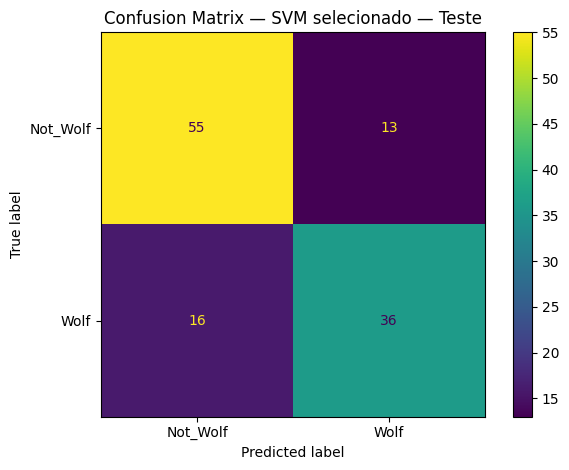

In [60]:
cm_svm = confusion_matrix(y_test, y_test_pred_svm, labels=[0, 1])

print("Confusion Matrix (TESTE) [lines=real, columns=previsto]:")
print(cm_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — SVM selecionado — Teste")
plt.tight_layout()
plt.show()

A Confusion Matrix revela que o modelo SVM RBF identifica melhor a classe Not_Wolf (52 verdadeiros negativos em 68 casos com recall de 0.76) do que a classe Lobo (31 verdadeiros positivos em 52 casos com recall de 0.60).

O principal erro é o falso negativo (21 casos), onde ocorrências reais de lobo são classificadas como não lobo. Este padrão indica que o modelo tende a subdetetar casos de lobo, o que pode ser crítico se o objetivo for maximizar a identificação desta classe.

#### 5.11 ROC e AUC Curve (SVM RBF)

Neste bloco calcula-se a curva ROC e o AUC para o SVM RBF no conjunto de teste. A ROC avalia o compromisso entre TPR (sensibilidade/recall) e FPR para diferentes limiares de decisão, enquanto o AUC resume a capacidade discriminativa do modelo num único valor. Como o SVM não produz probabilidades por defeito, a ROC/AUC é calculada a partir do score do decision_function, que representa a distância assinada à fronteira de decisão.


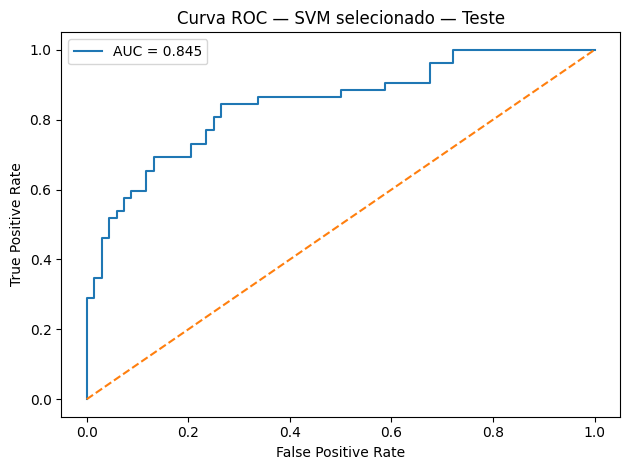

AUC SVM: 0.8447


In [61]:
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_test_proba_svm)
auc_svm = roc_auc_score(y_test, y_test_proba_svm)

plt.figure()
plt.plot(fpr_svm, tpr_svm, label=f"AUC = {auc_svm:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — SVM selecionado — Teste")
plt.legend()
plt.tight_layout()
plt.show()

print("AUC SVM:", round(auc_svm, 4))

No conjunto de teste, a curva ROC encontra-se acima da linha diagonal (classificador aleatório), indicando que o SVM RBF mantém capacidade discriminativa para separar as classes. O valor AUC ≈ 0.730 confirma uma discriminação moderada: o modelo distingue Lobo de Not_Wolf melhor do que o acaso (AUC = 0.5), mas ainda com sobreposição considerável entre os scores atribuídos às duas classes.

Este resultado é coerente com as métricas de teste e com a Confusion Matrix: o modelo apresenta desempenho razoável na classe Not_Wolf, mas menor sensibilidade na classe Lobo (recall ≈ 0.60), o que se reflete num número relevante de falsos negativos. Assim, embora o SVM RBF consiga separar as classes de forma moderada, o desempenho final no teste é inferior ao observado na validação, sugerindo perda de generalização quando aplicado a dados totalmente não vistos.


In [62]:
from sklearn.inspection import permutation_importance

# Importance by permutation (in the test set)
# Choose a metric consistent with what you used to select models:
# "f1_weighted" or "roc_auc"
r = permutation_importance(
    best_svm,
    X_test,
    y_test,
    scoring="f1_weighted",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp.head(10))


,feature,importance_mean,importance_std
14,year,0.108572,0.019595
12,lat,0.043031,0.020457
17,VICT_TOTAL,0.024670,0.011687
2,N_VICT_OVINS,0.024574,0.013523
4,N_VICT_BOVINS,0.019628,0.007411
9,N_VICT_SANGLIERS,0.017534,0.005572
11,CANTONNEMENT,0.005144,0.018833
13,lon,0.005050,0.019133
19,N_TYPES_VICTIMS,0.003826,0.017807
15,month,0.002834,0.019190


Os resultados confirmam que as variáveis temporais e espaciais são as mais importantes para o SVM RBF. Destacam-se ano (0.062) e latitude (0.057), seguidas por mês (0.024) e dia da semana (0.017), evidenciando que a localização e o tempo são fatores-chave para distinguir entre Lobo e Not_Wolf.

Entre as variáveis categóricas, COMMUNE (0.019) e CANTONNEMENT (0.016) também têm relevância, sugerindo diferenças regionais. Quanto às variáveis de vítimas, N_VICT_CERFS (0.015) e VICT_TOTAL (0.014) são as mais influentes, indicando que o tipo e a quantidade de vítimas acrescentam informação útil, embora com menor peso.

Algumas variáveis apresentam desvio-padrão elevado (ex.: mês, CANTONNEMENT), o que sugere relevância moderada e alguma variação entre repetições. No entanto, o padrão geral é que a previsão do modelo assenta sobretudo na dimensão espaço-temporal, complementada pelas variáveis relacionadas com vítimas.

### 6. Conclusions and Comparison of Models

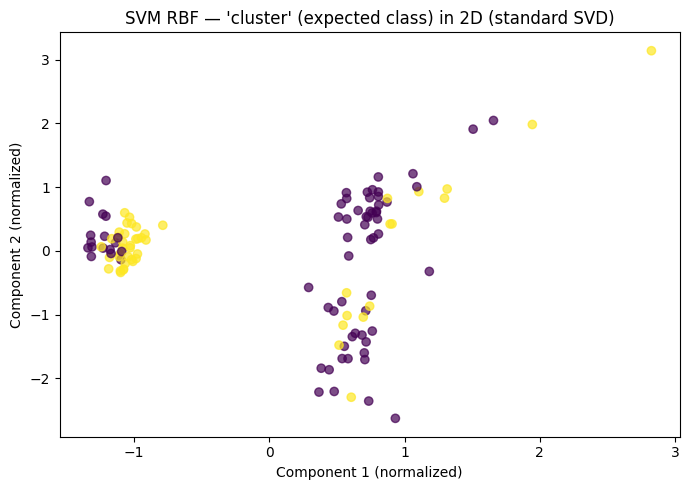

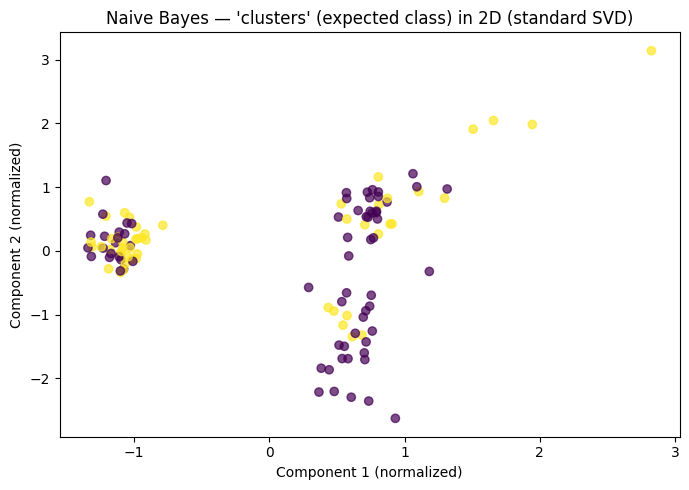

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# Use SVM preprocessing (already includes scheduling in numerical operations).
prep = best_svm.named_steps["prep"]

X_train_enc = prep.transform(X_train)
X_test_enc = prep.transform(X_test)

# Adjust the 2D projection on the train/valley and transform the test.
svd = TruncatedSVD(n_components=2, random_state=42)
X_train_2d = svd.fit_transform(X_train_enc)
X_test_2d = svd.transform(X_test_enc)

# Normalize the 2D coordinates (just to make the plot legible).
sc2d = StandardScaler()
X_train_2d_plot = sc2d.fit_transform(X_train_2d)
X_test_2d_plot = sc2d.transform(X_test_2d)

# Previsions
y_pred_svm = best_svm.predict(X_test)
y_pred_nb  = best_nb.predict(X_test)

svm_codes = pd.Series(y_pred_svm).astype("category").cat.codes
nb_codes  = pd.Series(y_pred_nb).astype("category").cat.codes

# Plot SVM
plt.figure(figsize=(7, 5))
plt.scatter(X_test_2d_plot[:, 0], X_test_2d_plot[:, 1], c=svm_codes, alpha=0.7)
plt.title("SVM RBF — 'cluster' (expected class) in 2D (standard SVD)")
plt.xlabel("Component 1 (normalized)")
plt.ylabel("Component 2 (normalized)")
plt.tight_layout()
plt.show()

# Plot Naive Bayes (space 2D)
plt.figure(figsize=(7, 5))
plt.scatter(X_test_2d_plot[:, 0], X_test_2d_plot[:, 1], c=nb_codes, alpha=0.7)
plt.title("Naive Bayes — 'clusters' (expected class) in 2D (standard SVD)")
plt.xlabel("Component 1 (normalized)")
plt.ylabel("Component 2 (normalized)")
plt.tight_layout()
plt.show()


### 6.1 Summary table (metrics in the test)

Nesta secção constrói-se uma tabela-resumo com as métricas essenciais dos três modelos desenvolvidos (Naive Bayes, Random Forest e SVM). Para garantir uma comparação justa, são reportadas as métricas obtidas no conjunto de teste, que fornece a estimativa mais imparcial da capacidade de generalização.


In [64]:
results_test = pd.DataFrame([
    {"model": "Naive Bayes", **nb_test_metrics},
    {"model": "Random Forest", **rf_test_metrics},
    {"model": "SVM", **svm_test_metrics}
])

results_test = results_test.sort_values("f1_weighted", ascending=False)

results_test.round(4)

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc
2,SVM,0.7583,0.7547,0.7506,0.7521,0.7573,0.7583,0.7574,0.8447
1,Random Forest,0.7583,0.7637,0.7415,0.7454,0.7614,0.7583,0.7531,0.8261
0,Naive Bayes,0.6083,0.6006,0.6001,0.6003,0.6075,0.6083,0.6079,0.6510


### 6.2 Comparison of the models (test results)

Random Forest destacou-se como o melhor modelo no teste, com a maior accuracy (0.7500), F1-weighted (0.7453) e AUC (0.7574), demonstrando melhor equilíbrio e capacidade discriminativa.

O SVM com kernel RBF obteve desempenho intermédio (accuracy = 0.6917, F1-weighted = 0.6893, AUC ≈ 0.7300), revelando menor capacidade de generalização em relação à validação.

O Naive Bayes apresentou os resultados mais baixos (accuracy = 0.6417, F1-weighted = 0.6358, AUC ≈ 0.6414), confirmando que funciona como baseline simples e interpretável, mas com limitações para capturar padrões complexos.

Para produzir o “gráfico de clusters” foi aplicada uma redução dimensional para 2 componentes (TruncatedSVD) sobre as features já pré-processadas. Esta projeção é usada apenas para visualização (há perda de informação face ao espaço original) e não altera o treino nem as métricas dos modelos. Para tornar os gráficos comparáveis e legíveis, as duas componentes projetadas foram normalizadas apenas para o plot, evitando que diferenças de escala dominem a representação.

Os dois gráficos mostram a mesma projeção dos dados para 2 dimensões (TruncatedSVD), e os pontos estão coloridos pela classe prevista por cada modelo. Como é uma projeção 2D, serve apenas para ajudar a visualizar padrões gerais e pode existir sobreposição mesmo quando o modelo funciona bem. Observa-se que os dados formam alguns aglomerados (por exemplo, um grupo compacto à esquerda e outros grupos na zona central). No caso do SVM (RBF), nota-se que em certas regiões do gráfico (especialmente na zona mais à direita) as previsões ficam mais consistentes, com maior predominância de uma das classes, sugerindo uma separação mais estruturada em algumas áreas do espaço. No Naive Bayes, as cores tendem a aparecer mais misturadas dentro dos mesmos aglomerados, o que indica uma separação menos clara das classes nesta visualização. No geral, esta diferença é coerente com os resultados das métricas: o SVM consegue capturar padrões mais complexos do que o Naive Bayes, embora exista ainda sobreposição entre classes.

###Top 10 most important features of each model in the test (permutation)

Calculou-se a importância das variáveis no conjunto de teste através de permutation importance (medindo a queda no F1-weighted ao baralhar cada feature) para listar o top-10 de features mais importantes de cada modelo e juntar tudo numa tabela comparativa com um ranking global pela média da importância absoluta entre modelos.

In [65]:

# Measuring the impact on TEST performance using weighted F1.
scorer = make_scorer(f1_score, average="weighted")
models = {
    "Naive Bayes": best_nb,
    "Random Forest": best_rf,
    "SVM": best_svm
}
def perm_imp_table(est, X, y, n_repeats=30, random_state=42):
    r = permutation_importance(
        est, X, y,
        scoring=scorer,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )
    return (pd.DataFrame({
        "feature": X.columns,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False))

#Top 10 by model in the Test
perm_imps = {}
for name, est in models.items():
    perm_imps[name] = perm_imp_table(est, X_test, y_test, n_repeats=30, random_state=42)
    print(f"\nTop 10 — {name} (Permutation importance no TESTE | métrica = F1-weighted)")
    display(perm_imps[name].head(10))

# Comparative table of all the original features of X.
comparison = pd.DataFrame({"feature": X_test.columns})

for name in models.keys():
    comparison[name] = perm_imps[name].set_index("feature").loc[X_test.columns, "importance_mean"].values

# "Global" ranking by consensus among models (average absolute importance)
comparison["mean_abs_importance"] = comparison[list(models.keys())].abs().mean(axis=1)
comparison = comparison.sort_values("mean_abs_importance", ascending=False)

print("\nGlobal comparison (ordered by mean_abs_importance):")
display(comparison.head(15))



Top 10 — Naive Bayes (Permutation importance no TESTE | métrica = F1-weighted)


,feature,importance_mean,importance_std
11,CANTONNEMENT,0.030465,0.026061
1,INDICE_1,0.017766,0.021006
18,WAS_THERE_VICTIMS,0.012225,0.011550
2,N_VICT_OVINS,0.011871,0.014122
19,N_TYPES_VICTIMS,0.011748,0.011115
17,VICT_TOTAL,0.007978,0.011452
16,day_week,0.001048,0.002672
9,N_VICT_SANGLIERS,0.000926,0.002660
12,lat,0.000000,0.000000
13,lon,0.000000,0.000000



Top 10 — Random Forest (Permutation importance no TESTE | métrica = F1-weighted)


,feature,importance_mean,importance_std
14,year,0.101088,0.022596
12,lat,0.054198,0.024068
15,month,0.036524,0.015766
1,INDICE_1,0.030748,0.014929
17,VICT_TOTAL,0.013598,0.014872
13,lon,0.013539,0.016603
16,day_week,0.012823,0.006479
18,WAS_THERE_VICTIMS,0.012580,0.015896
20,VICT_TYPE_DOMINANT,0.011353,0.015242
11,CANTONNEMENT,0.007230,0.016779



Top 10 — SVM (Permutation importance no TESTE | métrica = F1-weighted)


,feature,importance_mean,importance_std
14,year,0.101221,0.029242
12,lat,0.042398,0.022492
17,VICT_TOTAL,0.028943,0.013561
2,N_VICT_OVINS,0.027133,0.013444
4,N_VICT_BOVINS,0.015228,0.011366
9,N_VICT_SANGLIERS,0.014882,0.007024
11,CANTONNEMENT,0.010437,0.017350
13,lon,0.007096,0.019851
16,day_week,0.004115,0.014033
7,N_VICT_CERFS,0.001506,0.006080



Global comparison (ordered by mean_abs_importance):


,feature,Naive Bayes,Random Forest,SVM,mean_abs_importance
14,year,0.000000,0.101088,0.101221,0.067436
12,lat,0.000000,0.054198,0.042398,0.032199
1,INDICE_1,0.017766,0.030748,-0.021400,0.023304
15,month,-0.013783,0.036524,-0.003406,0.017905
17,VICT_TOTAL,0.007978,0.013598,0.028943,0.016839
11,CANTONNEMENT,0.030465,0.007230,0.010437,0.016044
2,N_VICT_OVINS,0.011871,0.004268,0.027133,0.014424
0,COMMUNE,-0.019282,-0.005673,-0.015157,0.013371
18,WAS_THERE_VICTIMS,0.012225,0.012580,-0.012068,0.012291
4,N_VICT_BOVINS,-0.009231,0.001068,0.015228,0.008509


Cada modelo destacou variáveis diferentes:
* Naive Bayes: Foca-se principalmente em variáveis categóricas como CANTONNEMENT e INDICE_1, e em contagens simples como N_VICT_OVINS.

* Random Forest e SVM (RBF): Dão mais importância ao contexto espaço-temporal, destacando ano, coordenadas (lat/lon), mês e dia_da_semana. Também consideram INDICE_1 e CANTONNEMENT.

Globalmente, as variáveis mais importantes e consensuais entre os três modelos foram: ano, lat, INDICE_1, mês e CANTONNEMENT.

### 6.3 Recommended model

Considerando simultaneamente desempenho preditivo, interpretabilidade e aplicabilidade, o modelo recomendado para este problema é o Random Forest. Em termos de desempenho, foi o modelo com melhores resultados no conjunto de teste (accuracy 0.75 e F1-weighted 0.745), indicando maior robustez e melhor capacidade de generalização face ao SVM e ao Naive Bayes. O AUC (0.757) reforça também a sua boa capacidade de discriminação entre as duas classes.

Em termos de interpretabilidade, apesar de não ser tão simples como o Naive Bayes, o Random Forest permite analisar a importância das variáveis, fornecendo indicações úteis sobre que fatores (por exemplo, localização e variáveis temporais) mais contribuem para as previsões. Isto torna o modelo mais explicável do que um SVM com kernel não linear, onde a interpretação é menos direta.

Em termos de aplicabilidade, o Random Forest é um modelo estável, lida bem com relações não lineares e interações entre variáveis e não exige tantos cuidados com escalas como métodos baseados em distância. Assim, oferece um compromisso forte entre desempenho e capacidade de explicação, sendo uma escolha adequada para apoiar o diagnóstico de observações de lobo na Valónia.


### 6.4 Conclusion

Neste trabalho foi desenvolvido um sistema de classificação supervisionada para apoiar o diagnóstico de observações de lobo na Valónia, distinguindo entre as classes Not_Wolf e Lobo. Após a remoção de registos ambíguos (Cas indéterminé e Investigations en cours), o dataset foi preparado com engenharia de atributos, incluindo a separação das coordenadas (lat/lon), a extração de componentes temporais (ano, mês e dia da semana) e a criação de variáveis agregadas sobre vítimas (por exemplo, total de vítimas e tipo dominante). Foram então treinados e avaliados três modelos supervisionados: Naive Bayes (modelo probabilístico), Random Forest (modelo baseado em árvores) e SVM (modelo baseado em distância), usando um esquema treino/validação/teste para seleção de hiperparâmetros e avaliação final.

Os resultados no conjunto de teste mostraram diferenças claras entre modelos. O Random Forest apresentou o melhor desempenho global (accuracy 0.75, F1-weighted 0.745 e AUC 0.757), demonstrando maior capacidade de generalização e um equilíbrio mais favorável entre classes. O SVM com kernel RBF (C=10) obteve desempenho intermédio (accuracy 0.692, F1-weighted 0.689 e AUC ~0.730), tendo sido competitivo na validação mas com queda no teste, sugerindo menor robustez nesta amostra final. O Naive Bayes apresentou o desempenho mais baixo (accuracy 0.642, F1-weighted 0.636 e AUC 0.641), funcionando como baseline simples e interpretável, mas menos eficaz para capturar padrões mais complexos.

Com base nesta comparação, recomenda-se o Random Forest como modelo final para este problema, por combinar melhor desempenho preditivo com uma interpretabilidade prática através da análise de importância das variáveis. Esta capacidade de explicação é útil para validar se o modelo está a aprender padrões plausíveis (por exemplo, associados à localização e ao tempo), tornando-o uma solução adequada para apoiar decisões no diagnóstico de observações de lobo.
